In [1]:
from sklearn.preprocessing import StandardScaler
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
import scipy
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpecFromSubplotSpec

plot_path = '/home/u/u241308/figures/'

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#anomaly reference period
ref_min = 1985
ref_max = 2014

In [3]:
#correlation time period
time_min = 1960
time_max = 2020

# Select lead years

In [4]:
lead_year = 1 #2

In [5]:
#1-13 for Dec-Nov first lead year, 13-25 for Dec-Nov second lead year
if lead_year == 1:
    lead_min = 0 # 2 to start in January, first lead year
    lead_max = 12 # 14 To end in December, first lead year
if lead_year == 2:
    lead_min = 12 # 14 to start in January, second lead year
    lead_max = 24 # 26 to end in December, second lead year

# SST

In [6]:
#select SPG area
lon_min_spg = -60
lon_max_spg = -10
lat_min_spg = 50
lat_max_spg = 66

In [7]:
#Hybrid ML
# Load, slice, and collect datasets
sliced_datasets = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_ML_NA/anomaly/'
    file = 'sst_%i_r1-16i2p3-LR_26_months_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_ML:
        sst_ML_ly1 = sst_ML.tos.isel(time=slice(lead_min,lead_max))
    sliced_datasets.append(sst_ML_ly1.mean(dim='time').expand_dims(predicted_year=[y_id]))

#concatenate along time dimension
sst_ML = xr.concat(sliced_datasets,dim='predicted_year')

#new longitudes
sst_ML['lon'] = np.where(sst_ML.lon > 180,sst_ML.lon-360,sst_ML.lon)
ind_sort = np.argsort(sst_ML.lon)
sst_ML = sst_ML[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (sst_ML.lon >= lon_min_spg) & (sst_ML.lon <= lon_max_spg)
lat_sel = (sst_ML.lat >= lat_min_spg) & (sst_ML.lat <= lat_max_spg)

sst_ML = sst_ML[:,:,lat_sel,lon_sel].mean(dim=('lon','lat'))

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_ML = sst_ML.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_ML = sst_ML.assign_coords(sfc=np.arange(1, 17))

##homogenize time dimension, so each month's time corresponds to the first day, and first our
#sst_ML['time'] = pd.to_datetime(sst_ML['time']) - pd.offsets.MonthBegin()
#sst_ML['time'] = sst_ML['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [8]:
#Standard
# Load, slice, and collect datasets
sliced_datasets = []
time_info = []
for y_id in range(time_min,time_max):
    path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/sst_benchmark/anomaly/'
    file = 'sst_%i_r1-16i2p2-LR_3_years_360x180_anomaly_ref_%i-%i.nc' %(y_id,ref_min,ref_max)
    with xr.open_dataset(path+file) as sst_MPI:
        sst_MPI_ly1 = sst_MPI.tos.isel(time=slice(lead_min,lead_max))
        time_info.append((sst_MPI_ly1.time.min(),sst_MPI_ly1.time.max()))     
    sliced_datasets.append(sst_MPI_ly1.mean(dim='time').expand_dims(predicted_year=[y_id]))

#concatenate along time dimension
sst_MPI = xr.concat(sliced_datasets,dim='predicted_year')

#new longitudes
sst_MPI['lon'] = np.where(sst_MPI.lon > 180,sst_MPI.lon-360,sst_MPI.lon)
ind_sort = np.argsort(sst_MPI.lon)
sst_MPI = sst_MPI[:,:,:,ind_sort.values]
#select lon/lat
lon_sel = (sst_MPI.lon >= lon_min_spg) & (sst_MPI.lon <= lon_max_spg)
lat_sel = (sst_MPI.lat >= lat_min_spg) & (sst_MPI.lat <= lat_max_spg)

sst_MPI = sst_MPI[:,:,lat_sel,lon_sel].mean(dim=('lon','lat'))

#change 'depth' dimension name to 'sfc', so the dimension name matches with z500 (only for ML, not for MPI)
sst_MPI = sst_MPI.rename({"depth": "sfc"})
#give different coordinates for each ensemble member in sfc:
sst_MPI = sst_MPI.assign_coords(sfc=np.arange(1, 17))

##homogenize time dimension, so each month's time corresponds to the first day, and first our
#sst_MPI['time'] = sst_MPI['time'].dt.floor('D')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [9]:
#ERA
path = '/work/uo1075/u241308/data_python_PostDoc/ML_assimilation/era5/'
file = 'era5_sst_1940-2023_360x180_anomaly_ref_%i-%i.nc' %(ref_min,ref_max)
sst_era = xr.open_dataset(path+file).sst

#new longitudes
sst_era['lon'] = np.where(sst_era.lon > 180,sst_era.lon-360,sst_era.lon)
ind_sort = np.argsort(sst_era.lon)
sst_era = sst_era[:,:,ind_sort.values]

#select lon/lat
lon_sel = (sst_era.lon >= lon_min_spg) & (sst_era.lon <= lon_max_spg)
lat_sel = (sst_era.lat >= lat_min_spg) & (sst_era.lat <= lat_max_spg)
sst_era = sst_era[:,lat_sel,lon_sel].mean(dim=('lon','lat'))

#homogenize to MPI and ML
sliced_datasets = []
for y_id,year in enumerate(np.arange(time_min,time_max)):
    sst_era_ly1 = sst_era[(sst_era.time.dt.floor('D')>=time_info[y_id][0].dt.floor('D'))&(sst_era.time.dt.floor('D')<=time_info[y_id][1].dt.floor('D'))]
    sliced_datasets.append(sst_era_ly1.mean(dim='time').expand_dims(predicted_year=[year]))

#concatenate along time dimension
sst_era = xr.concat(sliced_datasets,dim='predicted_year')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


# Plot

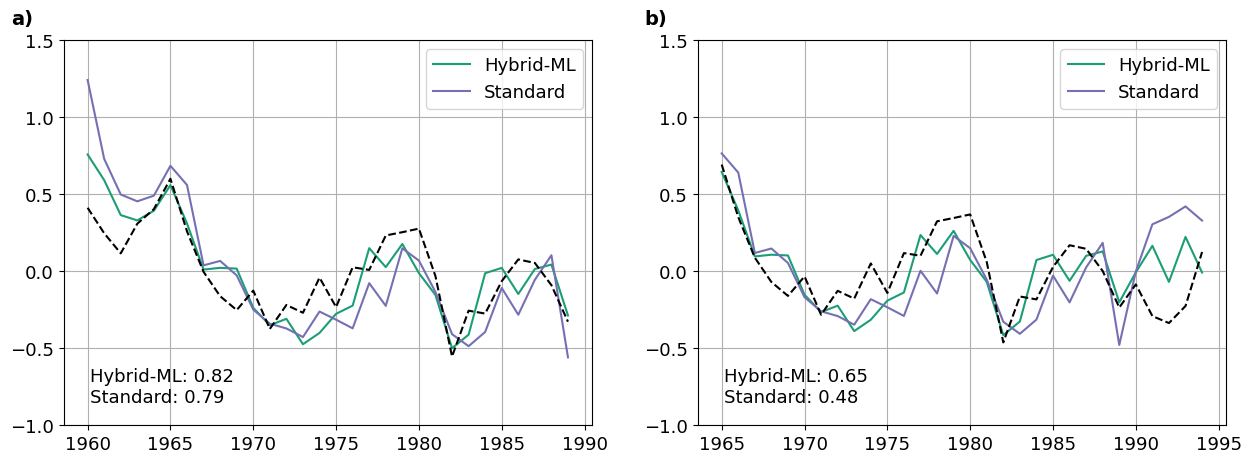

In [11]:
x_plot = np.arange(1960,2020)
fig = plt.figure(figsize=(15,5))#(15,10))
plt.rcParams.update({'font.size': 13})

MPI_color = '#7570b3'
ML_color = '#1b9e77'

ax1 = plt.subplot(1,2,1)
t_min = 0
t_max = 30
plt.plot(x_plot[t_min:t_max],sst_ML[t_min:t_max].mean(dim='sfc')-sst_ML[t_min:t_max].mean(dim=('sfc','predicted_year')),ML_color,label='Hybrid-ML')
plt.plot(x_plot[t_min:t_max],sst_MPI[t_min:t_max].mean(dim='sfc')-sst_MPI[t_min:t_max].mean(dim=('sfc','predicted_year')),MPI_color,label='Standard')
plt.plot(x_plot[t_min:t_max],sst_era[t_min:t_max]-sst_era[t_min:t_max].mean(dim=('predicted_year')),'--k')
plt.grid()
plt.ylim(-1,1.5)
x_corr = sst_era[t_min:t_max]
y_corr = sst_MPI[t_min:t_max].mean(dim='sfc')
mpi_corr = np.corrcoef(x_corr,y_corr)[0,1]
y_corr = sst_ML[t_min:t_max].mean(dim='sfc')
ml_corr = np.corrcoef(x_corr,y_corr)[0,1]
ax1.text(0.05, 0.15, 'Hybrid-ML: %2.2f \nStandard: %2.2f '%(ml_corr,mpi_corr), transform=ax1.transAxes,
                ha='left', va='top')
ax1.legend(loc='upper right')

ax2 = plt.subplot(1,2,2)
t_min = 5
t_max = 35
plt.plot(x_plot[t_min:t_max],sst_ML[t_min:t_max].mean(dim='sfc')-sst_ML[t_min:t_max].mean(dim=('sfc','predicted_year')),ML_color,label='Hybrid-ML')
plt.plot(x_plot[t_min:t_max],sst_MPI[t_min:t_max].mean(dim='sfc')-sst_MPI[t_min:t_max].mean(dim=('sfc','predicted_year')),MPI_color,label='Standard')
plt.plot(x_plot[t_min:t_max],sst_era[t_min:t_max]-sst_era[t_min:t_max].mean(dim=('predicted_year')),'--k')
plt.grid()
plt.ylim(-1,1.5)
x_corr = sst_era[t_min:t_max]
y_corr = sst_MPI[t_min:t_max].mean(dim='sfc')
mpi_corr = np.corrcoef(x_corr,y_corr)[0,1]
y_corr = sst_ML[t_min:t_max].mean(dim='sfc')
ml_corr = np.corrcoef(x_corr,y_corr)[0,1]
ax2.text(0.05, 0.15, 'Hybrid-ML: %2.2f \nStandard: %2.2f '%(ml_corr,mpi_corr), transform=ax2.transAxes,
                ha='left', va='top')
ax2.legend(loc='upper right')

x_pos = -0.1
y_pos = 1.08
labels = ["a)", "b)"]
axes_ = [ax1, ax2]
for lab, ax in zip(labels, axes_):
    ax.text(x_pos, y_pos, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=14, fontweight='bold')
    
plt.savefig(plot_path+'spg_tas_1leadyear_timeserie_timechuncks_anomaly_ref_%i-%i'%(
            ref_min,ref_max), bbox_inches="tight", dpi=100)